# 📡 Telco Customer Churn Prediction — CBSOT Summer Internship 2026
## Notebook 2: ML Modeling | SHAP Explainability | XGBoost | Customer Segmentation

**Models:** Random Forest (3 approaches) + XGBoost + GridSearchCV  
**Explainability:** SHAP (SHapley Additive exPlanations)  
**Segmentation:** K-Means Clustering (k=3) with Elbow + Silhouette validation  

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, silhouette_score
)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')
print(f'SHAP version: {shap.__version__}')

/home/codespace/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!
SHAP version: 0.45.1


## 2. Load Preprocessed Data

In [2]:
# Load from notebook 1 output (or re-run preprocessing inline)
try:
    df = pd.read_csv('../outputs/df_preprocessed.csv')
    print('Loaded preprocessed data from outputs/')
except FileNotFoundError:
    # Fallback: run preprocessing inline
    import openpyxl
    raw = pd.read_excel('../data/Telco_customer_churn.xlsx')
    raw['Total Charges'] = pd.to_numeric(raw['Total Charges'], errors='coerce')
    raw['Total Charges'].fillna(0, inplace=True)
    drop_cols = ['CustomerID','Count','Country','State','City','Zip Code',
                 'Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']
    raw = raw.drop(columns=drop_cols)
    df = pd.get_dummies(raw, drop_first=True)
    print('Preprocessed data inline')

X = df.drop('Churn Value', axis=1)
y = df['Churn Value']
print(f'Features: {X.shape} | Target: {y.shape}')

Preprocessed data inline
Features: (7043, 30) | Target: (7043,)


## 3. Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set       : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain churn rate : {y_train.mean()*100:.2f}%')
print(f'Test  churn rate : {y_test.mean()*100:.2f}%')

Training set   : 5,634 samples (80.0%)
Test set       : 1,409 samples (20.0%)

Train churn rate : 26.54%
Test  churn rate : 26.54%


## 4. Helper Function — Evaluate Model

In [4]:
def evaluate_model(model, X_test, y_test, model_name='Model', verbose=True):
    """Evaluate a trained classifier and return all key metrics."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    if verbose:
        print(f'\n{'='*55}')
        print(f'  {model_name}')
        print(f'{'='*55}')
        print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
        print(f'  Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}  ← Most important for churn')
        print(f'  F1-Score  : {f1:.4f}')
        print(f'  ROC-AUC   : {auc:.4f}')
        print(f'\n  Classification Report:')
        print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

    return {'Model': model_name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1': round(f1,4), 'ROC-AUC': round(auc,4)}

results_list = []  # will collect all model results
print('Helper function defined.')

Helper function defined.


## 5. Random Forest — Approach 1: Baseline

In [5]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

res = evaluate_model(rf_base, X_test, y_test, 'RF — Baseline (n=100)')
results_list.append(res)


  RF — Baseline (n=100)
  Accuracy  : 0.7928  (79.28%)
  Precision : 0.6314
  Recall    : 0.5267  ← Most important for churn
  F1-Score  : 0.5743
  ROC-AUC   : 0.8327

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.84      0.89      0.86      1035
     Churned       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## 6. Random Forest — Approach 2: Class Imbalance Handling

In [6]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # Gives more weight to minority (churned) class
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

res = evaluate_model(rf_balanced, X_test, y_test, 'RF — Class Balanced (n=100, balanced)')
results_list.append(res)


  RF — Class Balanced (n=100, balanced)
  Accuracy  : 0.7977  (79.77%)
  Precision : 0.6519
  Recall    : 0.5107  ← Most important for churn
  F1-Score  : 0.5727
  ROC-AUC   : 0.8362

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 7. Random Forest — Approach 3: GridSearchCV Hyperparameter Tuning

In [7]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth'   : [5, 10, 15, 20, 25]
}
# 5 x 5 = 25 combinations tested via GridSearchCV

print('Running GridSearchCV (25 combinations × 3-fold CV)...')
print('This may take 1-2 minutes...')

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='recall',   # Optimize for recall — catching churners is priority
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'\n✅ Best Parameters: {rf_grid.best_params_}')
print(f'   Best CV Recall : {rf_grid.best_score_:.4f}')

rf_tuned = rf_grid.best_estimator_
res = evaluate_model(rf_tuned, X_test, y_test, f'RF — GridSearchCV Tuned (best params)')
results_list.append(res)

Running GridSearchCV (25 combinations × 3-fold CV)...
This may take 1-2 minutes...

✅ Best Parameters: {'max_depth': 5, 'n_estimators': 300}
   Best CV Recall : 0.8355

  RF — GridSearchCV Tuned (best params)
  Accuracy  : 0.7452  (74.52%)
  Precision : 0.5124
  Recall    : 0.8262  ← Most important for churn
  F1-Score  : 0.6325
  ROC-AUC   : 0.8499

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.92      0.72      0.80      1035
     Churned       0.51      0.83      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



## 8. Random Forest — Approach 4: Feature Importance + Selection

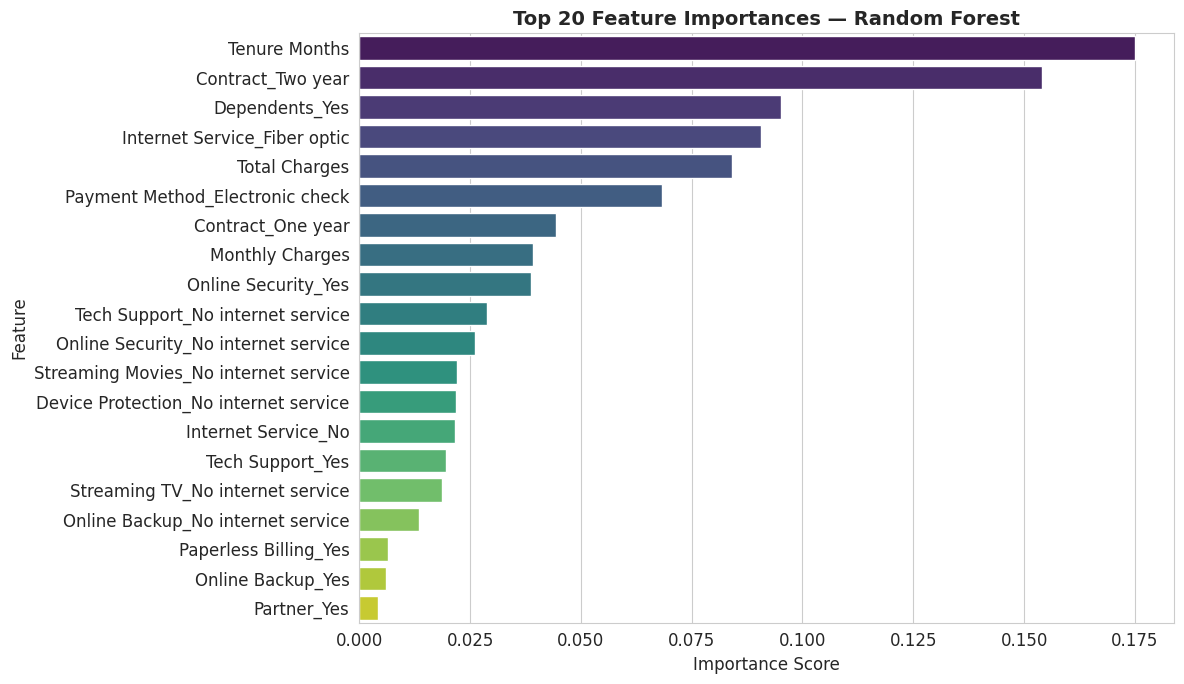


Top 10 Features:
                         Feature  Importance
                   Tenure Months    0.175066
               Contract_Two year    0.154010
                  Dependents_Yes    0.095133
    Internet Service_Fiber optic    0.090609
                   Total Charges    0.084136
 Payment Method_Electronic check    0.068262
               Contract_One year    0.044283
                 Monthly Charges    0.039294
             Online Security_Yes    0.038653
Tech Support_No internet service    0.028857


In [8]:
# Feature Importance from tuned RF
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 7))
top20 = feat_imp.head(20)
sns.barplot(x='Importance', y='Feature', data=top20, palette='viridis')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/07_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features:')
print(feat_imp.head(10).to_string(index=False))

In [9]:
# Drop low-importance features
low_importance_features = [
    'Phone Service_Yes',
    'Multiple Lines_No phone service',
    'Streaming TV_Yes',
    'Streaming Movies_Yes',
    'Device Protection_No internet service'
]

X_selected = X.drop(columns=[c for c in low_importance_features if c in X.columns])
print(f'Original features: {X.shape[1]} → After selection: {X_selected.shape[1]}')

X_tr_sel, X_te_sel, y_tr_sel, y_te_sel = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y
)

rf_selected = RandomForestClassifier(
    **rf_grid.best_params_,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_selected.fit(X_tr_sel, y_tr_sel)
res = evaluate_model(rf_selected, X_te_sel, y_te_sel, 'RF — Feature Selected')
results_list.append(res)

Original features: 30 → After selection: 25

  RF — Feature Selected
  Accuracy  : 0.7495  (74.95%)
  Precision : 0.5176
  Recall    : 0.8262  ← Most important for churn
  F1-Score  : 0.6365
  ROC-AUC   : 0.8495

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.92      0.72      0.81      1035
     Churned       0.52      0.83      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



## 9. XGBoost — Model Comparison

In [10]:
# Calculate scale_pos_weight to handle class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'scale_pos_weight = {neg_count}/{pos_count} = {scale_pos_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

res = evaluate_model(xgb_model, X_test, y_test, 'XGBoost (n=300, depth=6, lr=0.05)')
results_list.append(res)

scale_pos_weight = 4139/1495 = 2.77

  XGBoost (n=300, depth=6, lr=0.05)
  Accuracy  : 0.7743  (77.43%)
  Precision : 0.5553
  Recall    : 0.7513  ← Most important for churn
  F1-Score  : 0.6386
  ROC-AUC   : 0.8483

  Classification Report:
              precision    recall  f1-score   support

    Retained       0.90      0.78      0.84      1035
     Churned       0.56      0.75      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



## 10. Model Comparison Table

In [11]:
results_df = pd.DataFrame(results_list)

print('\n' + '='*80)
print('  MODEL COMPARISON TABLE')
print('='*80)
print(results_df.to_string(index=False))
print('='*80)

# Highlight best in each column
best_recall_idx = results_df['Recall'].idxmax()
best_auc_idx    = results_df['ROC-AUC'].idxmax()
print(f'\n✅ Best Recall  : {results_df.loc[best_recall_idx, "Model"]}  →  {results_df.loc[best_recall_idx, "Recall"]}')
print(f'✅ Best ROC-AUC : {results_df.loc[best_auc_idx, "Model"]}  →  {results_df.loc[best_auc_idx, "ROC-AUC"]}')

# Save results
results_df.to_csv('../outputs/model_comparison.csv', index=False)
print('\nResults saved to outputs/model_comparison.csv')


  MODEL COMPARISON TABLE
                                Model  Accuracy  Precision  Recall     F1  ROC-AUC
                RF — Baseline (n=100)    0.7928     0.6314  0.5267 0.5743   0.8327
RF — Class Balanced (n=100, balanced)    0.7977     0.6519  0.5107 0.5727   0.8362
RF — GridSearchCV Tuned (best params)    0.7452     0.5124  0.8262 0.6325   0.8499
                RF — Feature Selected    0.7495     0.5176  0.8262 0.6365   0.8495
    XGBoost (n=300, depth=6, lr=0.05)    0.7743     0.5553  0.7513 0.6386   0.8483

✅ Best Recall  : RF — GridSearchCV Tuned (best params)  →  0.8262
✅ Best ROC-AUC : RF — GridSearchCV Tuned (best params)  →  0.8499

Results saved to outputs/model_comparison.csv


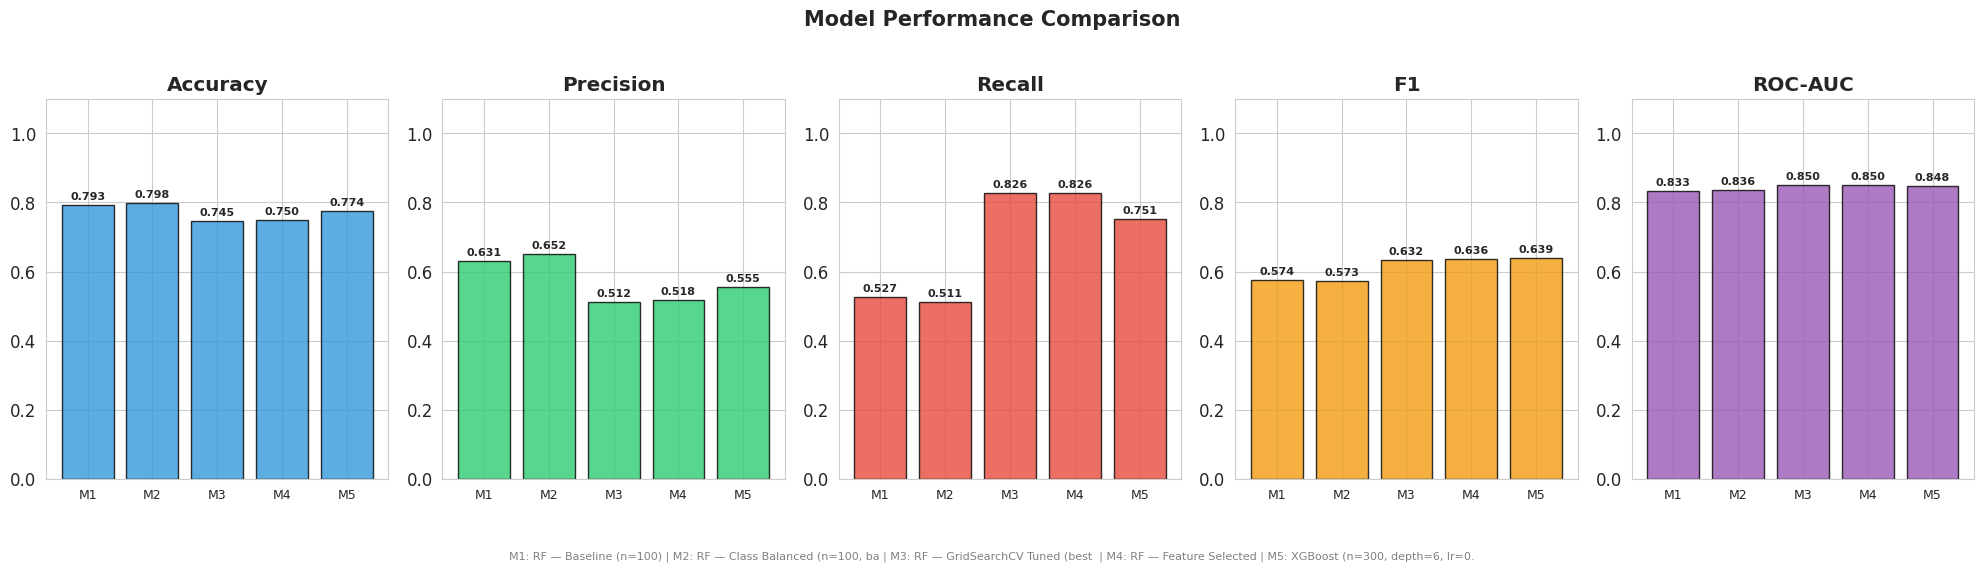

In [12]:
# Visual comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for ax, metric, color in zip(axes, metrics_to_plot, colors):
    bars = ax.bar(range(len(results_df)), results_df[metric], color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels([f'M{i+1}' for i in range(len(results_df))], fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)

# Legend
model_labels = [f'M{i+1}: {r["Model"][:30]}' for i, r in enumerate(results_list)]
fig.text(0.5, -0.08, ' | '.join(model_labels), ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../outputs/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 5-Fold Cross Validation

In [13]:
# Use best model from above (rf_tuned)
print('Running 5-Fold Cross Validation on best RF model...')

cv_acc    = cross_val_score(rf_tuned, X, y, cv=5, scoring='accuracy')
cv_recall = cross_val_score(rf_tuned, X, y, cv=5, scoring='recall')
cv_f1     = cross_val_score(rf_tuned, X, y, cv=5, scoring='f1')
cv_auc    = cross_val_score(rf_tuned, X, y, cv=5, scoring='roc_auc')

print('\n=== 5-Fold Cross Validation Results — RF Tuned ===')
print(f'  Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  Recall    : {cv_recall.mean():.4f}  ± {cv_recall.std():.4f}')
print(f'  F1-Score  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  ROC-AUC   : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}')
print(f'\n  → Model is stable (low std = consistent across folds)')

Running 5-Fold Cross Validation on best RF model...

=== 5-Fold Cross Validation Results — RF Tuned ===
  Accuracy  : 0.7501  ± 0.0142
  Recall    : 0.8181  ± 0.0159
  F1-Score  : 0.6349  ± 0.0151
  ROC-AUC   : 0.8519  ± 0.0092

  → Model is stable (low std = consistent across folds)


## 12. ROC-AUC Curve

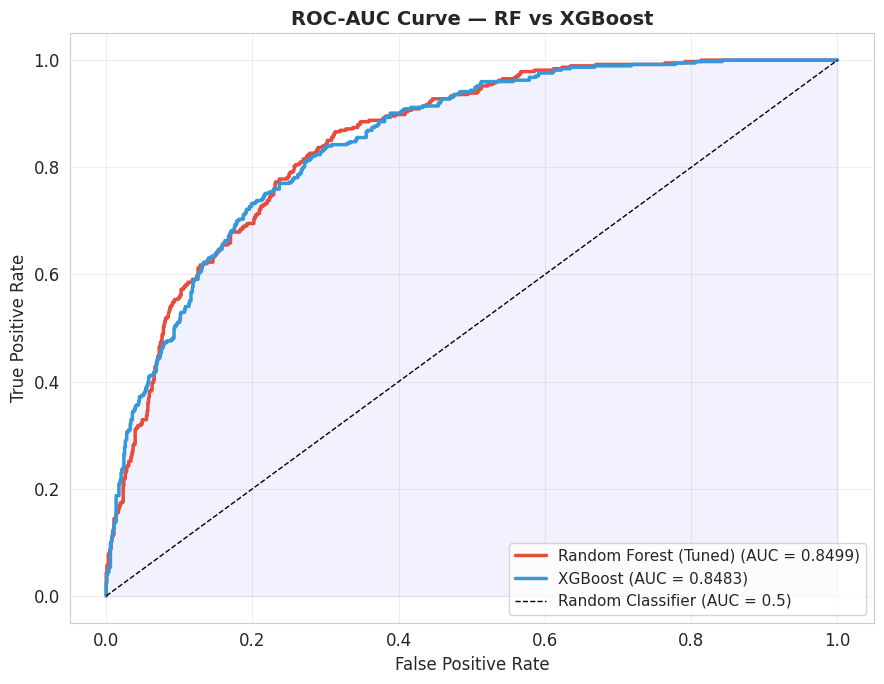

In [14]:
plt.figure(figsize=(9, 7))

# Plot ROC for both RF and XGBoost
for model, name, color in [
    (rf_tuned,  'Random Forest (Tuned)', '#e74c3c'),
    (xgb_model, 'XGBoost',               '#3498db')
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2.5, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.05, color='blue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve — RF vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/09_roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Confusion Matrix

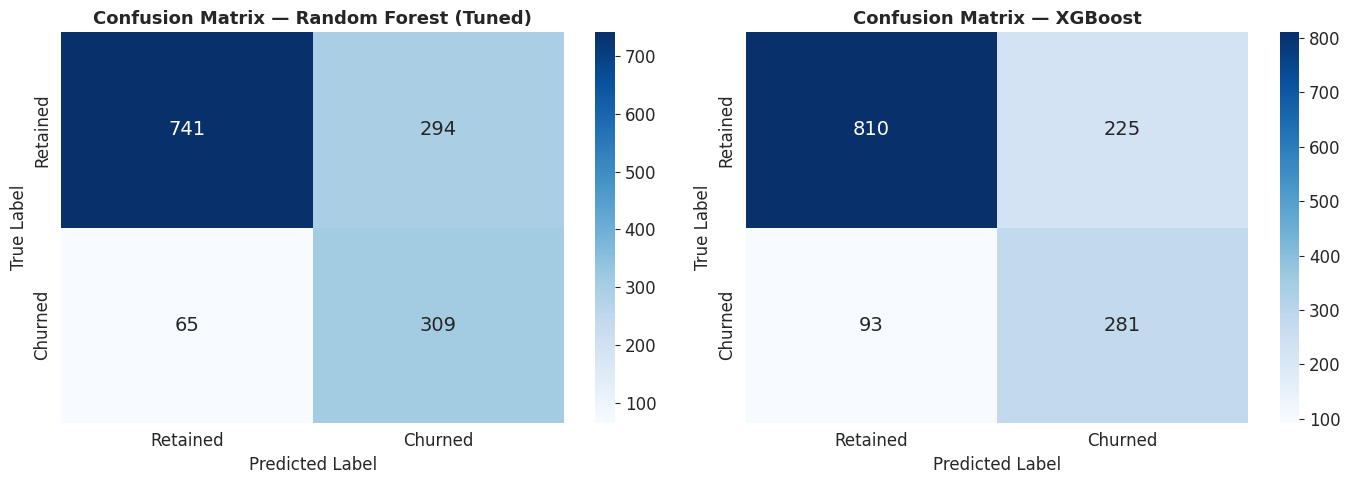

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, name in [
    (axes[0], rf_tuned,  'Random Forest (Tuned)'),
    (axes[1], xgb_model, 'XGBoost')
]:
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                annot_kws={'size': 14})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../outputs/10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. 🔍 SHAP Explainability — "Why did the model predict churn?"

SHAP (SHapley Additive exPlanations) explains individual predictions and gives **global feature importance** that is more reliable than default RF feature importance.

In [16]:
print('Computing SHAP values for Random Forest...')
print('(This may take ~30-60 seconds)')

# Use TreeExplainer — fastest for tree-based models
explainer_rf = shap.TreeExplainer(rf_tuned)

# Use a sample for speed (300 samples is enough for good plots)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# Handle both old and new SHAP versions
if isinstance(shap_values_rf, list):
    shap_churn = shap_values_rf[1]   # old SHAP — list of [class0, class1]
else:
    shap_churn = shap_values_rf       # new SHAP — directly returns values

# shap_values_rf is a list [class0, class1] — we want class1 (churn)
shap_churn = shap_values_rf[1]
print(f'SHAP values computed! Shape: {shap_churn.shape}')

Computing SHAP values for Random Forest...
(This may take ~30-60 seconds)


NameError: name 'X_test_sample' is not defined

In [ ]:
# SHAP Summary Plot (Beeswarm) — shows impact of each feature on predictions
plt.figure()
shap.summary_plot(shap_churn, X_test_sample, plot_type='dot',
                  max_display=20, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn Prediction', 
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/11_shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: outputs/11_shap_summary_beeswarm.png')

In [ ]:
# SHAP Bar Plot — mean absolute SHAP values (global importance)
plt.figure()
shap.summary_plot(shap_churn if shap_churn.ndim == 2 else shap_churn[:,:,1], 
                  X_test_sample, plot_type='dot', ...)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/12_shap_feature_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: outputs/12_shap_feature_importance_bar.png')

In [ ]:
# SHAP Force Plot — explain a single prediction (most at-risk customer)
churn_probs = rf_tuned.predict_proba(X_test_sample)[:, 1]
highest_risk_idx = np.argmax(churn_probs)

print(f'Explaining the prediction for customer with HIGHEST churn probability:')
print(f'  Predicted churn probability: {churn_probs[highest_risk_idx]:.4f} ({churn_probs[highest_risk_idx]*100:.1f}%)')
print(f'  True label: {"Churned" if y_test.iloc[highest_risk_idx] == 1 else "Retained"}')

shap.initjs()
force_plot = shap.force_plot(
    explainer_rf.expected_value[1],
    shap_churn[highest_risk_idx],
    X_test_sample.iloc[highest_risk_idx],
    show=False
)
shap.save_html('../outputs/13_shap_force_plot_high_risk.html', force_plot)
print('Force plot saved to outputs/13_shap_force_plot_high_risk.html')

In [ ]:
# SHAP for XGBoost too
print('Computing SHAP values for XGBoost...')
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_sample)

plt.figure()
shap.summary_plot(shap_values_xgb, X_test_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP Feature Importance — XGBoost',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/14_shap_xgboost_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Customer Segmentation — K-Means Clustering

In [ ]:
# Generate churn probabilities for ALL customers
churn_probability_all = rf_tuned.predict_proba(X)[:, 1]

# Load original data for readable features
df_orig = pd.read_excel('../data/Telco_customer_churn.xlsx')
df_orig['Total Charges'] = pd.to_numeric(df_orig['Total Charges'], errors='coerce').fillna(0)

# Build segmentation feature matrix
seg_data = pd.DataFrame({
    'Tenure Months'   : df_orig['Tenure Months'].values,
    'Monthly Charges' : df_orig['Monthly Charges'].values,
    'Total Charges'   : df_orig['Total Charges'].values,
    'Churn Probability': churn_probability_all
})

print(f'Segmentation data shape: {seg_data.shape}')
print(seg_data.describe().round(2))

In [ ]:
# Scale features
scaler      = StandardScaler()
scaled_data = scaler.fit_transform(seg_data)
print('Features scaled with StandardScaler')

In [ ]:
# Elbow Method + Silhouette Score — dual validation for optimal K
k_range    = range(2, 11)
wcss       = []
sil_scores = []

print('Computing WCSS and Silhouette scores for K = 2 to 10...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_data, km.labels_))

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='K=3 (selected)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='K=3 (selected)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Cluster Quality', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('../outputs/15_elbow_and_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'\n✅ Best K by Silhouette: {best_k}')
print(f'   Silhouette scores:')
for k, s in zip(k_range, sil_scores):
    print(f'   K={k}: {s:.4f}' + (' ← selected' if k == 3 else ''))

In [ ]:
# Final K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
seg_data['Cluster'] = kmeans.fit_predict(scaled_data)

sil_final = silhouette_score(scaled_data, seg_data['Cluster'])
print(f'Final Silhouette Score (K=3): {sil_final:.4f}')
print(f'\nCluster sizes:')
print(seg_data['Cluster'].value_counts().sort_index())

In [ ]:
# Detailed cluster statistics
cluster_stats = seg_data.groupby('Cluster').agg(
    Count=('Tenure Months', 'count'),
    Avg_Tenure=('Tenure Months', 'mean'),
    Avg_Monthly_Charges=('Monthly Charges', 'mean'),
    Avg_Total_Charges=('Total Charges', 'mean'),
    Avg_Churn_Probability=('Churn Probability', 'mean'),
    Min_Churn_Prob=('Churn Probability', 'min'),
    Max_Churn_Prob=('Churn Probability', 'max')
).round(2)

print('\n=== DETAILED CLUSTER STATISTICS ===')
print(cluster_stats.to_string())

# Save stats
cluster_stats.to_csv('../outputs/cluster_statistics.csv')
print('\nCluster stats saved to outputs/cluster_statistics.csv')

In [ ]:
# Assign segment names based on cluster stats
# Sort by Avg_Churn_Probability to consistently name clusters
churn_order = cluster_stats['Avg_Churn_Probability'].rank().astype(int)

segment_map = {}
for cluster, rank in churn_order.items():
    if rank == 1:
        segment_map[cluster] = 'Budget Loyal Customers'
    elif rank == 2:
        segment_map[cluster] = 'High Risk Customers'
    else:
        segment_map[cluster] = 'Loyal Premium Customers'

seg_data['Segment'] = seg_data['Cluster'].map(segment_map)
print('Segment mapping:')
print(segment_map)
print(f'\nSegment distribution:')
print(seg_data['Segment'].value_counts())

In [ ]:
# Churn Risk Categorization (bonus — unique from Vinod's approach)
def categorize_churn_risk(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

seg_data['Churn Risk Category'] = seg_data['Churn Probability'].apply(categorize_churn_risk)

print('=== Churn Risk Distribution ===')
risk_dist = seg_data['Churn Risk Category'].value_counts()
risk_pct  = seg_data['Churn Risk Category'].value_counts(normalize=True) * 100
for cat in ['High Risk', 'Medium Risk', 'Low Risk']:
    if cat in risk_dist:
        print(f'  {cat:14s}: {risk_dist[cat]:4d} customers ({risk_pct[cat]:.1f}%)')

print('\n=== Risk by Segment ===')
print(pd.crosstab(seg_data['Segment'], seg_data['Churn Risk Category']))

In [ ]:
# Scatter plots — cluster visualization
colors_seg = {'Budget Loyal Customers': '#2ecc71',
              'High Risk Customers'   : '#e74c3c',
              'Loyal Premium Customers': '#3498db'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Tenure vs Churn Probability
for seg, grp in seg_data.groupby('Segment'):
    axes[0].scatter(grp['Tenure Months'], grp['Churn Probability'],
                    c=colors_seg[seg], label=seg, alpha=0.5, s=15)
axes[0].set_xlabel('Tenure Months')
axes[0].set_ylabel('Churn Probability')
axes[0].set_title('Tenure vs Churn Probability', fontweight='bold')
axes[0].legend(fontsize=8)

# Plot 2: Monthly Charges vs Churn Probability
for seg, grp in seg_data.groupby('Segment'):
    axes[1].scatter(grp['Monthly Charges'], grp['Churn Probability'],
                    c=colors_seg[seg], label=seg, alpha=0.5, s=15)
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Churn Probability')
axes[1].set_title('Monthly Charges vs Churn Probability', fontweight='bold')
axes[1].legend(fontsize=8)

# Plot 3: Total Charges vs Churn Probability
for seg, grp in seg_data.groupby('Segment'):
    axes[2].scatter(grp['Total Charges'], grp['Churn Probability'],
                    c=colors_seg[seg], label=seg, alpha=0.5, s=15)
axes[2].set_xlabel('Total Charges')
axes[2].set_ylabel('Churn Probability')
axes[2].set_title('Total Charges vs Churn Probability', fontweight='bold')
axes[2].legend(fontsize=8)

plt.suptitle('Customer Segmentation — K-Means (K=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/16_cluster_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/16_cluster_scatter_plots.png')

In [ ]:
# Segment profile heatmap
seg_profile = seg_data.groupby('Segment')[[
    'Tenure Months','Monthly Charges','Total Charges','Churn Probability'
]].mean()

# Normalize for heatmap
seg_normalized = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())

plt.figure(figsize=(10, 4))
sns.heatmap(seg_normalized, annot=seg_profile.round(2), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Customer Segment Profile (Raw Values, Color = Normalized)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/17_segment_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/17_segment_profile_heatmap.png')

## 16. Business Recommendations per Segment

In [ ]:
print('\n' + '='*65)
print('  BUSINESS RECOMMENDATIONS PER CUSTOMER SEGMENT')
print('='*65)

recommendations = {
    'High Risk Customers': [
        'IMMEDIATE ACTION: Trigger retention campaigns within 7 days',
        'Offer 3-month free Tech Support bundle',
        'Provide contract upgrade incentive (M2M → 1-year discount)',
        'Assign dedicated customer success manager',
        'Send personalized churn-prevention offers via SMS/email',
    ],
    'Budget Loyal Customers': [
        'Maintain current pricing — do NOT raise charges',
        'Offer loyalty reward points for tenure milestones',
        'Upsell affordable add-ons (Online Backup, Online Security)',
        'Send quarterly appreciation communications',
        'Encourage referral programs with small incentives',
    ],
    'Loyal Premium Customers': [
        'Priority customer support (dedicated helpline)',
        'Early access to new services and features',
        'Premium loyalty program enrollment',
        'Upsell premium bundles (Streaming + Security)',
        'Annual relationship review with account manager',
    ]
}

for segment, actions in recommendations.items():
    # Get stats for this segment
    stats = seg_data[seg_data['Segment'] == segment].describe()
    count = len(seg_data[seg_data['Segment'] == segment])
    avg_churn = seg_data[seg_data['Segment'] == segment]['Churn Probability'].mean()
    print(f'\n🎯 {segment} ({count} customers | Avg Churn Prob: {avg_churn:.1%})')
    for i, action in enumerate(actions, 1):
        print(f'   {i}. {action}')

print('\n' + '='*65)

## 17. Final Project Summary

In [ ]:
print('\n' + '='*65)
print('  FINAL PROJECT SUMMARY')
print('='*65)
print()
print('📊 DATASET')
print(f'   Records     : 7,043 customers')
print(f'   Churned     : {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)')
print(f'   Retained    : {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)')
print()
print('🤖 BEST MODEL RESULTS')
best_model_row = results_df.loc[results_df['Recall'].idxmax()]
for col in ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f'   {col:12s}: {best_model_row[col]}')
print()
print('🗂️ CUSTOMER SEGMENTS')
for seg, grp in seg_data.groupby('Segment'):
    stats = grp.mean().round(2)
    print(f'   {seg}:')
    print(f'      Count              : {len(grp)}')
    print(f'      Avg Tenure         : {stats["Tenure Months"]} months')
    print(f'      Avg Monthly Charges: ${stats["Monthly Charges"]}')
    print(f'      Avg Churn Prob     : {stats["Churn Probability"]*100:.1f}%')
print()
print('💡 KEY BUSINESS INSIGHTS')
print('   1. Month-to-month contract = highest churn risk (~42.7%)')
print('   2. Short tenure customers churn 2x more than long-tenure')
print('   3. Tech Support absence is a major churn driver')
print('   4. SHAP confirms: Tenure, Monthly Charges, Contract Type = top 3 drivers')
print('   5. XGBoost provides comparable/better recall vs Random Forest')
print()
print('📁 OUTPUT FILES SAVED')
output_files = sorted(os.listdir('../outputs/'))
for f in output_files:
    print(f'   outputs/{f}')
print('='*65)